In [6]:
import requests
import csv
import pandas as pd
import math
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import time
import random
from datetime import datetime, date
import statistics
import requests
from scipy.stats import skew, kurtosis
from scipy import stats
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from scipy import stats
from scipy.stats import johnsonsu
from scipy.optimize import minimize
from scipy.stats import norm

In [7]:
def get_ff(interval='monthly', first_date_filter=None, quarterly='No'):
    key='&apikey=ZKMMTO1ATDBLXH2K'
    ff_url = f'https://www.alphavantage.co/query?function=FEDERAL_FUNDS_RATE&interval={interval}'+key
    r = requests.get(ff_url)
    ff = r.json()
    ff_data = ff['data']

    ff_ts_df = pd.DataFrame.from_dict(ff_data)
    ff_ts_df['date'] = pd.to_datetime(ff_ts_df['date'])
    ff_ts_df['value'] = ff_ts_df['value'].astype(float)

    if first_date_filter is not None:
        first_date_filter = pd.to_datetime(first_date_filter)
        ff_ts_df = ff_ts_df[ff_ts_df['date'] >= first_date_filter]

    ff_ts_df = ff_ts_df.sort_values(by='date', ascending=True)

    if str(quarterly).strip().lower() == 'yes':
        ff_ts_df = (
            ff_ts_df
            .set_index('date')
            .resample('QS')
            .mean()
            .reset_index()
        )

    return ff_ts_df

In [8]:
ff_rates = get_ff(first_date_filter='1980-01-01')
ff_rates

,date,value
556,1980-01-01,13.82
555,1980-02-01,14.13
554,1980-03-01,17.19
553,1980-04-01,17.61
552,1980-05-01,10.98
...,...,...
4,2026-01-01,3.64
3,2026-02-01,3.64
2,2026-03-01,3.64
1,2026-04-01,3.64


In [9]:
ff_logr = np.log(ff_rates['value'] / ff_rates['value'].shift(1))
ff_rates['logr'] = ff_logr
ff_rates = ff_rates.dropna()
ff_rates

,date,value,logr
555,1980-02-01,14.13,0.022183
554,1980-03-01,17.19,0.196028
553,1980-04-01,17.61,0.024139
552,1980-05-01,10.98,-0.472391
551,1980-06-01,9.47,-0.147947
...,...,...,...
4,2026-01-01,3.64,-0.021740
3,2026-02-01,3.64,0.000000
2,2026-03-01,3.64,0.000000
1,2026-04-01,3.64,0.000000


In [10]:
# ARMA(p,q) grid search on monthly Fed funds log changes — p,q ∈ {0,1,2,3,4}
from statsmodels.tsa.arima.model import ARIMA
from itertools import product

y = ff_rates['logr'].values

arma_results = []
for p, q in product(range(5), range(5)):
    try:
        fit = ARIMA(y, order=(p, 0, q)).fit()
        arma_results.append({'p': p, 'q': q, 'AIC': fit.aic, 'BIC': fit.bic})
    except Exception:
        arma_results.append({'p': p, 'q': q, 'AIC': np.nan, 'BIC': np.nan})

arma_df = (
    pd.DataFrame(arma_results)
    .dropna()
    .assign(order=lambda df: df.apply(lambda r: f"ARMA({int(r.p)},{int(r.q)})", axis=1))
    .sort_values('AIC')
    .reset_index(drop=True)
)

print('All ARMA(p,q) models — sorted by AIC (lower is better)\n')
print(arma_df[['order', 'p', 'q', 'AIC', 'BIC']].round(2).to_string(index=False))

best_aic = arma_df.iloc[0]
best_bic = arma_df.loc[arma_df['BIC'].idxmin()]
print(f"\nBest by AIC: {best_aic['order']}  (AIC={best_aic['AIC']:.2f}, BIC={best_aic['BIC']:.2f})")
print(f"Best by BIC: {best_bic['order']}  (AIC={best_bic['AIC']:.2f}, BIC={best_bic['BIC']:.2f})")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to conver

All ARMA(p,q) models — sorted by AIC (lower is better)

    order  p  q     AIC     BIC
ARMA(1,2)  1  2 -487.49 -465.89
ARMA(0,1)  0  1 -486.66 -473.70
ARMA(1,3)  1  3 -485.79 -459.86
ARMA(2,2)  2  2 -485.77 -459.85
ARMA(1,1)  1  1 -485.40 -468.12
ARMA(0,2)  0  2 -485.24 -467.96
ARMA(2,1)  2  1 -484.72 -463.11
ARMA(0,3)  0  3 -484.56 -462.95
ARMA(2,3)  2  3 -483.88 -453.63
ARMA(1,4)  1  4 -483.81 -453.56
ARMA(3,2)  3  2 -483.78 -453.54
ARMA(3,0)  3  0 -483.64 -462.04
ARMA(4,3)  4  3 -483.00 -444.11
ARMA(3,1)  3  1 -482.73 -456.81
ARMA(0,4)  0  4 -482.63 -456.71
ARMA(4,2)  4  2 -482.56 -448.00
ARMA(2,0)  2  0 -482.08 -464.80
ARMA(3,3)  3  3 -481.87 -447.31
ARMA(4,0)  4  0 -481.64 -455.72
ARMA(2,4)  2  4 -480.80 -446.23
ARMA(4,1)  4  1 -480.79 -450.55
ARMA(3,4)  3  4 -479.47 -440.58
ARMA(4,4)  4  4 -479.06 -435.85
ARMA(1,0)  1  0 -476.32 -463.36
ARMA(0,0)  0  0 -378.95 -370.31

Best by AIC: ARMA(1,2)  (AIC=-487.49, BIC=-465.89)
Best by BIC: ARMA(0,1)  (AIC=-486.66, BIC=-473.70)


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Fitted ARMA(1,2) on monthly ff_rates['logr']
  AIC = -487.49,  BIC = -465.89


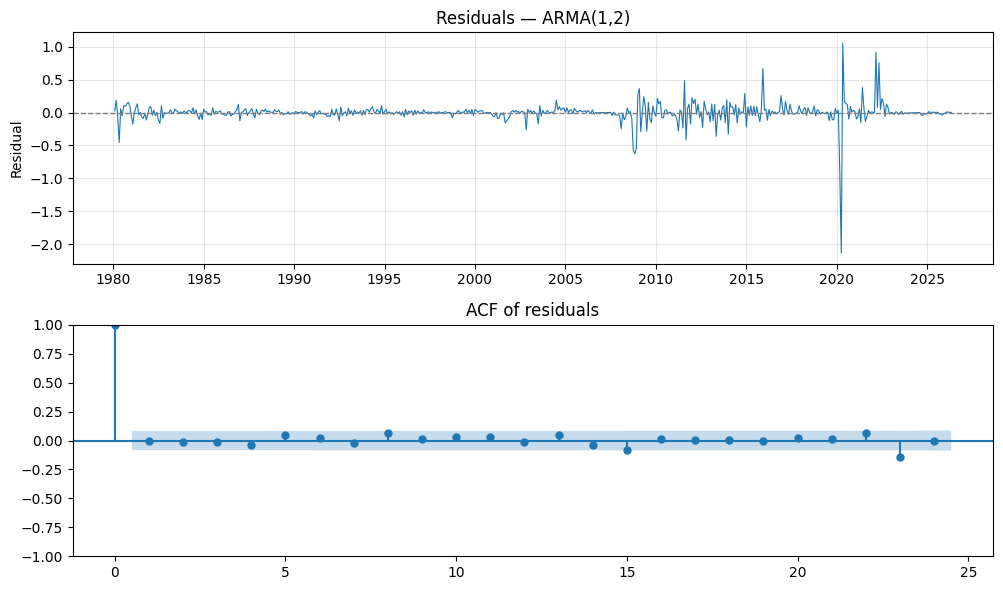

In [11]:
# Fit best model (by AIC) and plot residuals
best_p, best_q = int(best_aic['p']), int(best_aic['q'])
best_fit = ARIMA(y, order=(best_p, 0, best_q)).fit()

resid = pd.Series(best_fit.resid, index=pd.to_datetime(ff_rates['date']), name='residual')

print(f"Fitted {best_aic['order']} on monthly ff_rates['logr']")
print(f"  AIC = {best_fit.aic:.2f},  BIC = {best_fit.bic:.2f}")

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

axes[0].plot(resid.index, resid.values, linewidth=0.8)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[0].set_title(f'Residuals — {best_aic["order"]}')
axes[0].set_ylabel('Residual')
axes[0].grid(True, alpha=0.3)

from statsmodels.graphics.tsaplots import plot_acf
plot_acf(resid.dropna(), lags=24, ax=axes[1])
axes[1].set_title('ACF of residuals')
plt.tight_layout()
plt.show()

In [12]:
coefs = pd.Series(best_fit.params, index=best_fit.param_names)
pvals = pd.Series(best_fit.pvalues, index=best_fit.param_names)
phis = coefs.filter(like='ar.')
thetas = coefs.filter(like='ma.')
print('AR coefficients (φ):')
print(phis.round(4))
print('\nMA coefficients (θ):')
print(thetas.round(4))

AR coefficients (φ):
ar.L1    0.8798
dtype: float64

MA coefficients (θ):
ma.L1   -0.4136
ma.L2   -0.3483
dtype: float64
